In [1]:
#Read the datasets
import pandas as pd
import pandas as pd


df1 = pd.read_csv("../../Data/atlas_vivli_2004_2024.csv", low_memory=False)

print("Dataset 1:", df1.shape)

df1.head()
#Basic Dataset Information
print("\nDataset Information")
print(df1.info())

print("\nMissing Values")
print(df1.isnull().sum().sort_values(ascending=False).head(20))

Dataset 1: (1011168, 127)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1011168 entries, 0 to 1011167
Columns: 127 entries, Isolate Id to VIM
dtypes: float64(6), int64(1), str(120)
memory usage: 979.8 MB
None

Missing Values
Aztreonam avibactam_I       1011168
Gatifloxacin_I              1011168
Sulbactam_I                 1011168
Cefoperazone sulbactam_I    1011168
GIM                         1011168
SPM                         1011163
CMY I/MOX                   1011152
FOX                         1011127
ACC                         1011102
Gatifloxacin                1011095
Tetracycline                1011095
Tetracycline_I              1011095
PER                         1010973
CTX-M-8/25                  1010968
ACT/MIR                     1010956
IMP                         1010741
GES                         1010585
VEB                         1010541
CTX-M-2                     1010438
AMPC                        1009917
dtype: int64


In [2]:
missing_percent = (
    df1.isnull()
       .mean()
       .mul(100)
       .sort_values(ascending=False)
)

missing_percent.head(30)

Aztreonam avibactam_I          100.000000
Gatifloxacin_I                 100.000000
Sulbactam_I                    100.000000
Cefoperazone sulbactam_I       100.000000
GIM                            100.000000
SPM                             99.999506
CMY I/MOX                       99.998418
FOX                             99.995945
ACC                             99.993473
Gatifloxacin                    99.992781
Tetracycline                    99.992781
Tetracycline_I                  99.992781
PER                             99.980715
CTX-M-8/25                      99.980221
ACT/MIR                         99.979034
IMP                             99.957772
GES                             99.942344
VEB                             99.937992
CTX-M-2                         99.927806
AMPC                            99.876282
DHA                             99.817637
VIM                             99.781243
CMY2                            99.755135
Quinupristin dalfopristin       99

In [3]:
#Missing < 80% → Keep.
#Missing ≥ 80% → Consider removing or analyzing separately.
keep_columns = missing_percent[missing_percent < 80].index.tolist()
remove_columns = missing_percent[missing_percent >= 80].index.tolist()

print("Columns to keep:", len(keep_columns))
print("Columns to remove:", len(remove_columns))

Columns to keep: 61
Columns to remove: 66


In [4]:
#Organism distribution 
df1["Species"].value_counts()

Species
Staphylococcus aureus       172883
Escherichia coli            125878
Pseudomonas aeruginosa      115807
Klebsiella pneumoniae       106946
Streptococcus pneumoniae     49165
                             ...  
Stenotrophomonas spp             1
Mixta calida                     1
Bacillus spp                     1
Phocaeicola massiliensis         1
Burkholderia spp                 1
Name: count, Length: 400, dtype: int64

In [5]:
#Country distribution
df1["Country"].value_counts()

Country
United States    165880
Spain             65418
France            62065
Germany           59538
Italy             55705
                  ...  
Namibia             139
Mauritius           119
Indonesia            88
Nicaragua            46
Estonia              14
Name: count, Length: 83, dtype: int64

In [6]:
#Source distribution
df1["Source"].value_counts()

Source
Blood                     195510
Wound                     145010
Urine                     132751
Sputum                    131072
Endotracheal aspirate      47769
                           ...  
Transtracheal Aspirate         2
Bronchiole                     2
Vomit                          1
Ileum                          1
Pyoderma Lesion                1
Name: count, Length: 97, dtype: int64

In [7]:
#Age group distribution
df1["Age Group"].value_counts()

Age Group
61+        485088
31 - 60    323686
0 - 17     111787
18 - 30     72343
Unknown     18264
Name: count, dtype: int64

In [8]:
#Gender distribution
df1["Gender"].value_counts()

Gender
Male       563055
Female     437279
Unknown     10834
Name: count, dtype: int64

In [9]:
# Sampling changed over time
df1["Year"].value_counts().sort_index()

Year
2004    20101
2005    21801
2006    29940
2007    39964
2008    36773
2009    41692
2010    32462
2011    26023
2012    51066
2013    70125
2014    70529
2015    64785
2016    69598
2017    58271
2018    47798
2019    57339
2020    60382
2021    62692
2022    57751
2023    47713
2024    44363
Name: count, dtype: int64

In [10]:
gene_cols = [
    "IMP","KPC","NDM","OXA","PER","SHV","SPM","TEM","VEB","VIM" #Resistance genes to study
]
# Binary matrix for analysis
genes_binary = df1[gene_cols].notna().astype(int)

In [11]:
# AMR burden calculation
df1["AMR_Burden"] = genes_binary.sum(axis=1)
# 3. Sort by AMR_Burden (Descending) to get "Higher burden" at the top
result = df1.sort_values(by="AMR_Burden", ascending=False)
print(result[["AMR_Burden"] + gene_cols].head(10))


        AMR_Burden  IMP    KPC    NDM      OXA  PER       SHV  SPM  \
776653           5  NaN  KPC-2    NaN      NaN  NaN  SHV-OSBL  NaN   
968524           5  NaN  KPC-3  NDM-1  OXA-232  NaN    SHV-11  NaN   
815646           5  NaN  KPC-2    NaN      NaN  NaN  SHV-OSBL  NaN   
786184           5  NaN  KPC-3  NDM-1   OXA-48  NaN  SHV-OSBL  NaN   
988309           5  NaN  KPC-2  NDM-1      NaN  NaN     SHV-1  NaN   
936018           5  NaN  KPC-2    NaN      NaN  NaN  SHV-OSBL  NaN   
626301           4  NaN  KPC-2  NDM-1      NaN  NaN  SHV-OSBL  NaN   
976483           4  NaN    NaN  NDM-5   OXA-48  NaN    SHV-11  NaN   
610409           4  NaN  KPC-2    NaN      NaN  NaN  SHV-OSBL  NaN   
610408           4  NaN  KPC-2    NaN      NaN  NaN  SHV-OSBL  NaN   

                    TEM     VEB     VIM  
776653         TEM-OSBL   VEB-1   VIM-1  
968524            TEM-1     NaN     NaN  
815646         TEM-OSBL  VEB-25   VIM-1  
786184         TEM-OSBL     NaN     NaN  
988309  TEM-1; TEM-

In [12]:

# Gene prevalence
gene_prevalence = genes_binary.mean() * 100

gene_prevalence = gene_prevalence.sort_values(
    ascending=False
)

print(gene_prevalence)


TEM    2.880431
SHV    2.762943
OXA    0.564694
KPC    0.526817
NDM    0.498631
VIM    0.218757
VEB    0.062008
IMP    0.042228
PER    0.019285
SPM    0.000494
dtype: float64


In [13]:
print("TEM Positive Isolates:", genes_binary["TEM"].sum())

print("Total Isolates:", len(df1))

print(
    "TEM Prevalence:",
    round(genes_binary["TEM"].mean()*100,2),
    "%"
)

TEM Positive Isolates: 29126
Total Isolates: 1011168
TEM Prevalence: 2.88 %


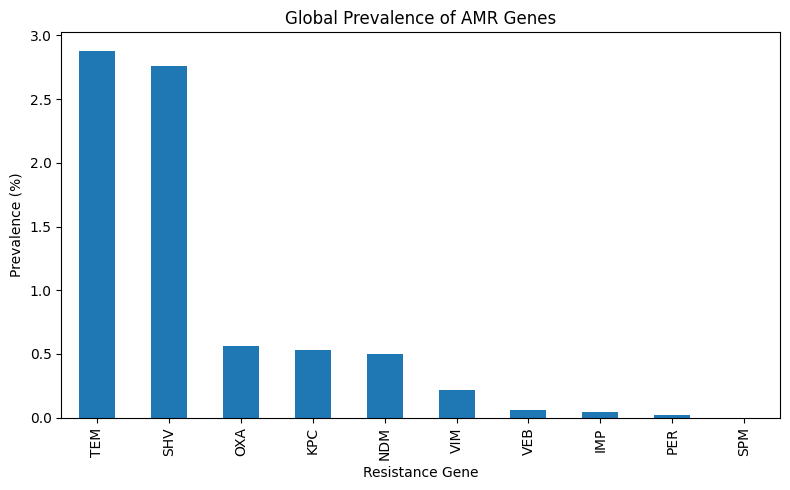

In [14]:
import matplotlib.pyplot as plt

gene_prevalence.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Prevalence (%)")
plt.xlabel("Resistance Gene")
plt.title("Global Prevalence of AMR Genes")

plt.tight_layout()
plt.savefig(
    "../../outputs/figures/most_prevalence_gene.png"
)

plt.show()

In [15]:
#Gene Prevalemce by country
country_gene = (
    df1.groupby("Country")[gene_cols]
       .apply(lambda x: x.notna().mean() * 100)
)

country_gene.head()

,IMP,KPC,NDM,OXA,PER,SHV,SPM,TEM,VEB,VIM
Country,,,,,,,,,,
Argentina,0.066523,2.078829,0.742835,0.493375,0.072066,4.057875,0.000000,4.218637,0.005544,0.072066
Australia,0.122604,0.000000,0.022292,0.050156,0.000000,0.663174,0.000000,0.813642,0.022292,0.005573
Austria,0.019829,0.277613,0.000000,0.138806,0.019829,1.368233,0.000000,1.427722,0.039659,0.317271
Belgium,0.003237,0.042082,0.090638,0.326945,0.006474,1.654150,0.000000,1.676810,0.000000,0.178040
Brazil,0.036401,4.871686,1.201238,0.303343,0.006067,7.061821,0.024267,6.600740,0.018201,0.066735


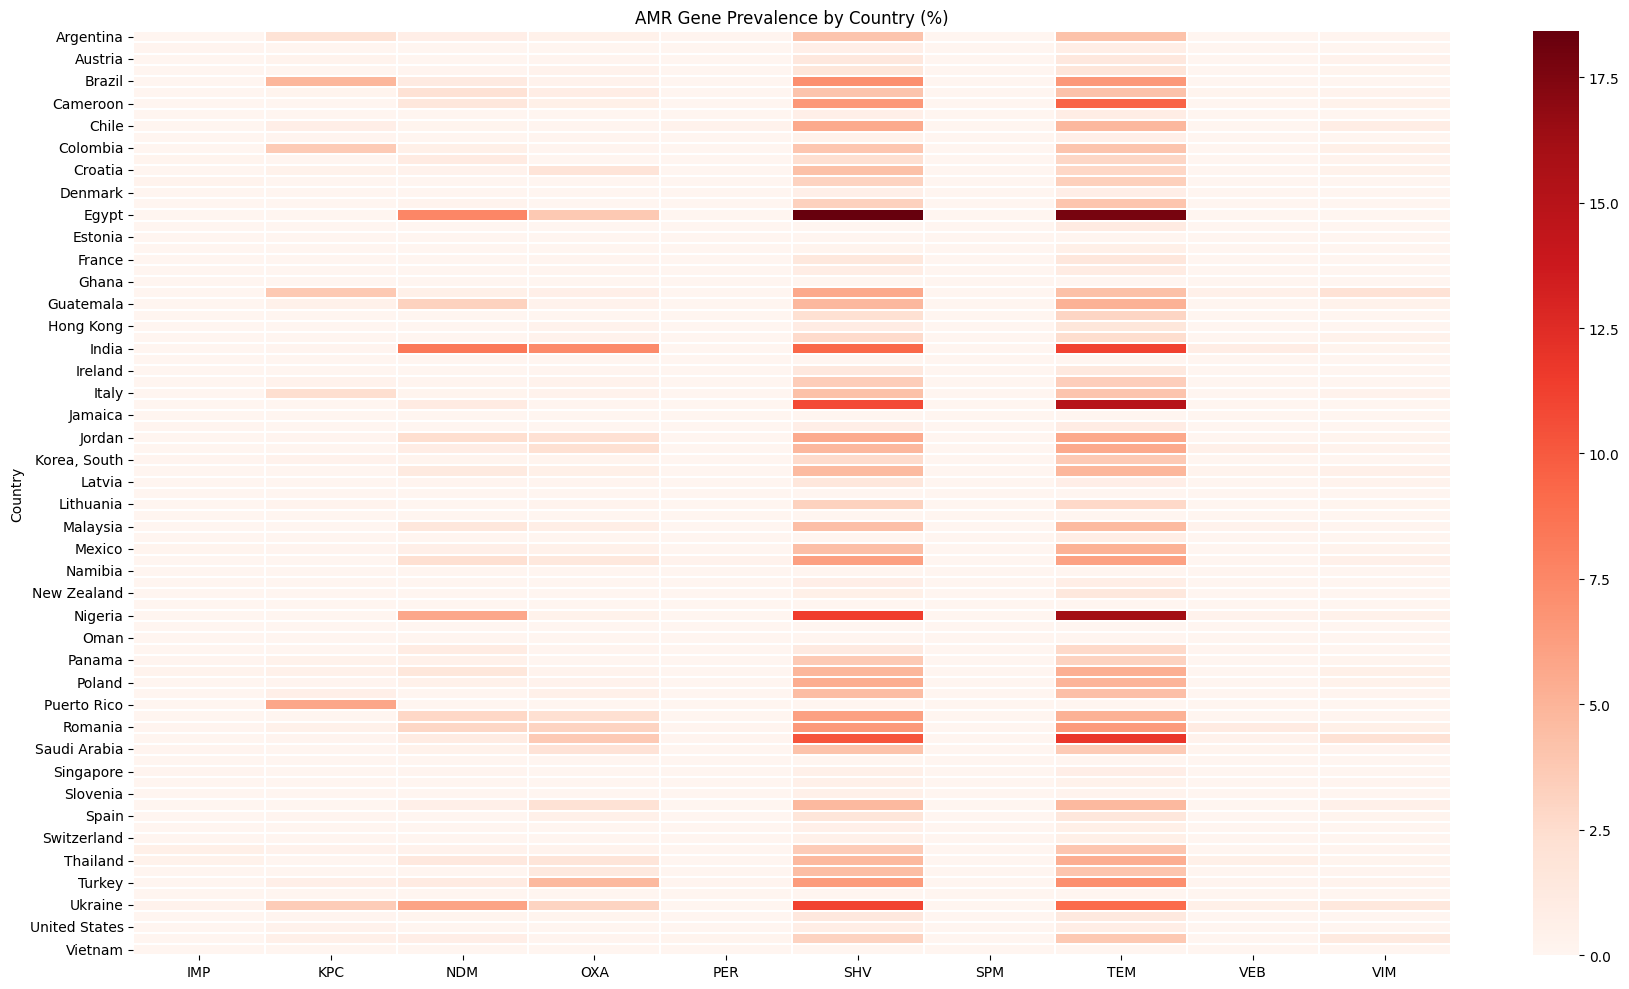

In [16]:
#Visualize gene prevalence by country
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

sns.heatmap(
    country_gene,
    cmap="Reds",
    linewidths=0.2
)

plt.title("AMR Gene Prevalence by Country (%)")
plt.tight_layout()
plt.savefig(
    "../../outputs/figures/gene_prevalence_by_country.png"
)
plt.show()

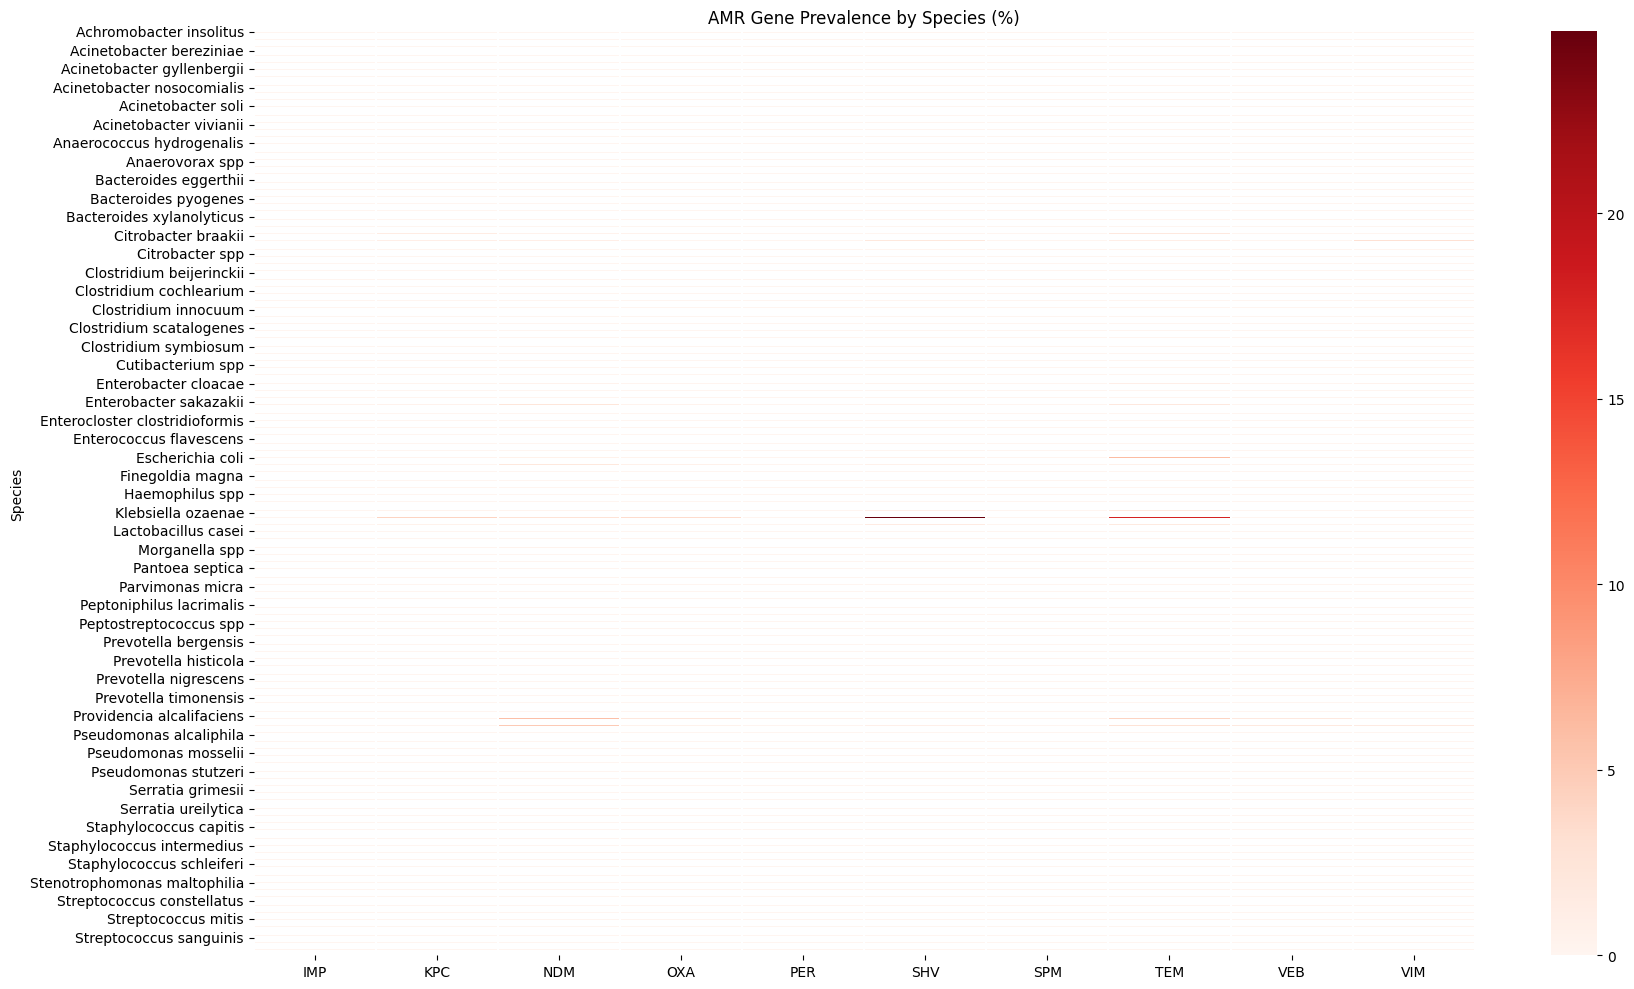

In [17]:
#Gene Prevalence by bacterial species
species_gene = (
    df1.groupby("Species")[gene_cols]
       .apply(lambda x: x.notna().mean() * 100)
)
#Visualize gene prevalence by bacterial species
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

sns.heatmap(
    species_gene,
    cmap="Reds",
    linewidths=0.2
)

plt.title("AMR Gene Prevalence by Species (%)")
plt.tight_layout()
plt.savefig(
    "../../outputs/figures/gene_prevalence_by_species.png"
)
plt.show()

Species
Klebsiella pneumoniae          0.533559
Klebsiella spp                 0.326340
Providencia spp                0.187919
Providencia rettgeri           0.147102
Providencia stuartii           0.128837
Enterobacter hormaechi         0.125851
Proteus mirabilis              0.082996
Citrobacter farmeri            0.078431
Escherichia coli               0.075359
Raoultella planticola          0.066667
Enterobacter xiangfangensis    0.063830
Enterobacter spp               0.062843
Citrobacter spp                0.062344
Citrobacter sedlakii           0.061856
Citrobacter freundii           0.053071
Enterobacter roggenkampii      0.052632
Serratia spp                   0.048423
Raoultella ornithinolytica     0.045662
Klebsiella variicola           0.045032
Citrobacter amalonaticus       0.041860
Name: AMR_Burden, dtype: float64


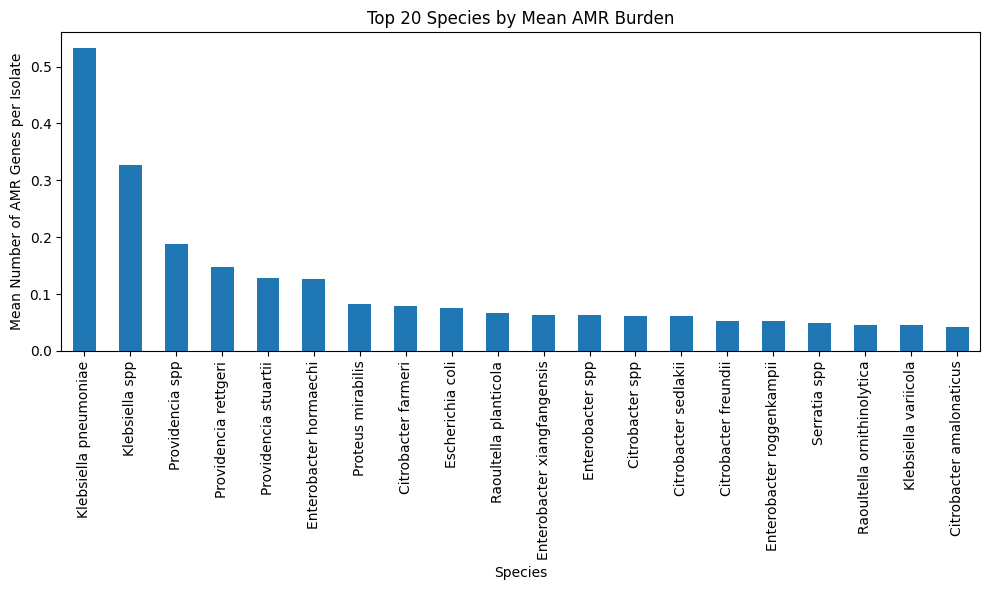

In [18]:

df1["AMR_Burden"] = genes_binary.sum(axis=1)
#Burden by organism
species_burden = (
    df1.groupby("Species")["AMR_Burden"]
       .mean()
       .sort_values(ascending=False)
)

print(species_burden.head(20))

#Visualize AMR burden by species
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

species_burden.head(20).plot(kind="bar")

plt.title("Top 20 Species by Mean AMR Burden")
plt.ylabel("Mean Number of AMR Genes per Isolate")
plt.xlabel("Species")
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(
    "../../outputs/figures/amr_burden_by_species.png"
)
plt.show()

In [19]:
#Country-wise AMR burden
country_gene = df1.groupby("Country")[gene_cols].apply(lambda x: x.notna().mean() * 100)
country_gene.head(10)

,IMP,KPC,NDM,OXA,PER,SHV,SPM,TEM,VEB,VIM
Country,,,,,,,,,,
Argentina,0.066523,2.078829,0.742835,0.493375,0.072066,4.057875,0.000000,4.218637,0.005544,0.072066
Australia,0.122604,0.000000,0.022292,0.050156,0.000000,0.663174,0.000000,0.813642,0.022292,0.005573
Austria,0.019829,0.277613,0.000000,0.138806,0.019829,1.368233,0.000000,1.427722,0.039659,0.317271
Belgium,0.003237,0.042082,0.090638,0.326945,0.006474,1.654150,0.000000,1.676810,0.000000,0.178040
Brazil,0.036401,4.871686,1.201238,0.303343,0.006067,7.061821,0.024267,6.600740,0.018201,0.066735
Bulgaria,0.036350,0.181752,2.144675,0.908760,0.000000,4.071247,0.000000,4.216648,0.181752,0.254453
Cameroon,0.000000,0.000000,1.522843,0.634518,0.000000,6.598985,0.000000,9.517766,0.000000,0.380711
Canada,0.011885,0.051504,0.059427,0.019809,0.003962,0.701240,0.000000,0.887445,0.011885,0.007924
Chile,0.000000,0.744794,0.151999,0.136799,0.311598,5.585955,0.000000,4.772762,0.000000,0.919593


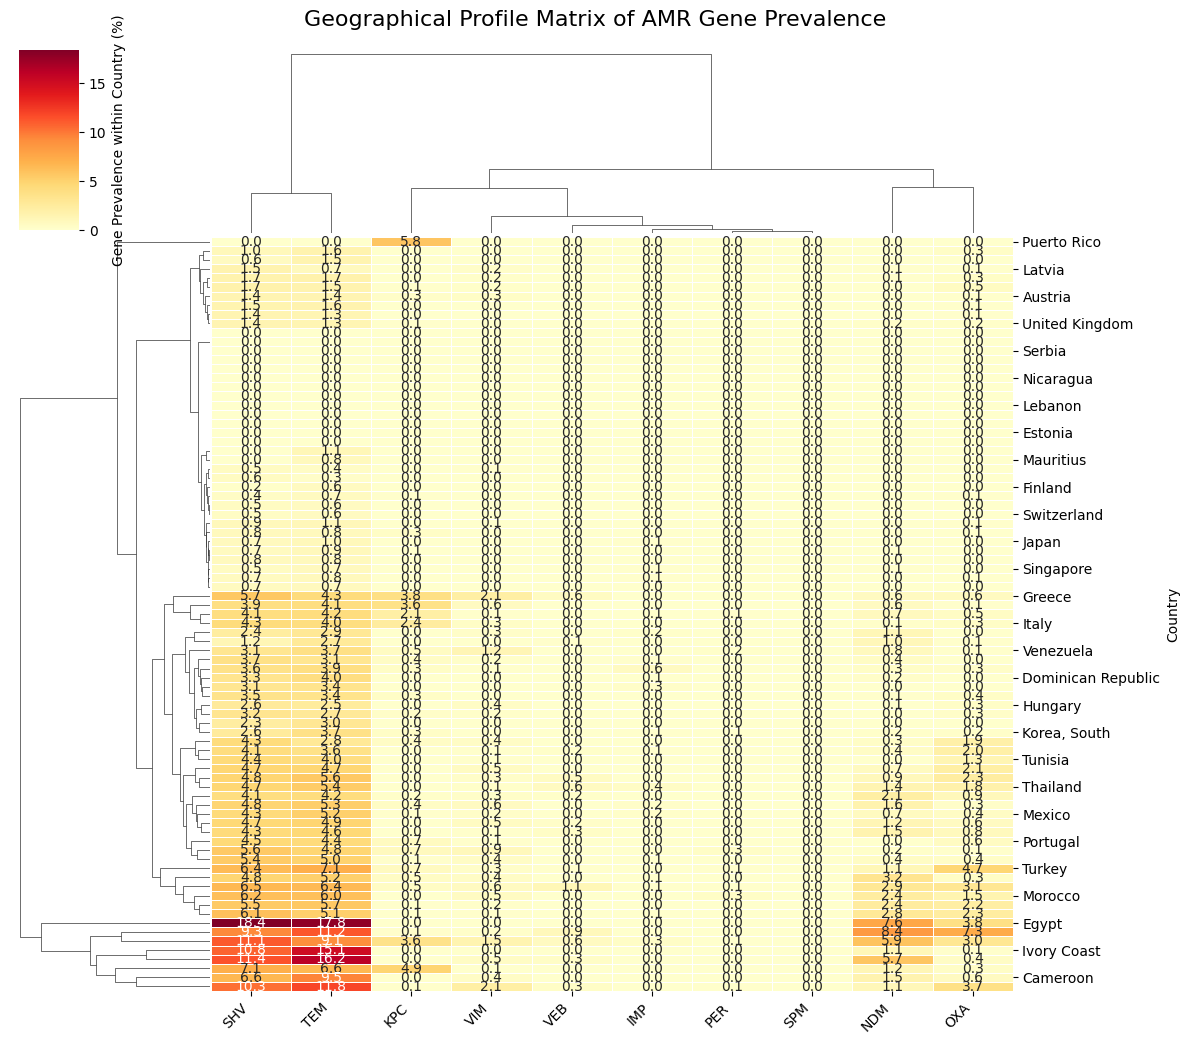

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the country-wise gene prevalence matrix (Fixing the grouping behavior)
country_gene = (
    df1.groupby("Country")[gene_cols]
    .apply(lambda x: x.notna().mean() * 100)
)

# hierarchical clustered heatmap (clustermap)
# Using sns.clustermap automatically groups countries with similar superbug signatures together!
g = sns.clustermap(
    country_gene,
    cmap="YlOrRd",       # Yellow-Orange-Red gradient shows escalating severity beautifully
    annot=True,          # Displays the exact percentage numbers inside the cells
    fmt=".1f",           # Formats to one decimal place
    linewidths=0.5,      # Adds subtle grids between cells to keep it organized
    figsize=(12, 10),    # Gives the country labels room to breathe
    cbar_kws={'label': 'Gene Prevalence within Country (%)'}
)

# Adjust titles and styling on the cluster axes
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, horizontalalignment='right')
g.fig.suptitle("Geographical Profile Matrix of AMR Gene Prevalence", fontsize=16, y=1.02)

#  Save with an accurate, descriptive filename
g.savefig("../../outputs/figures/country_wise_gene_profiles.png", dpi=300, bbox_inches='tight')
plt.show()

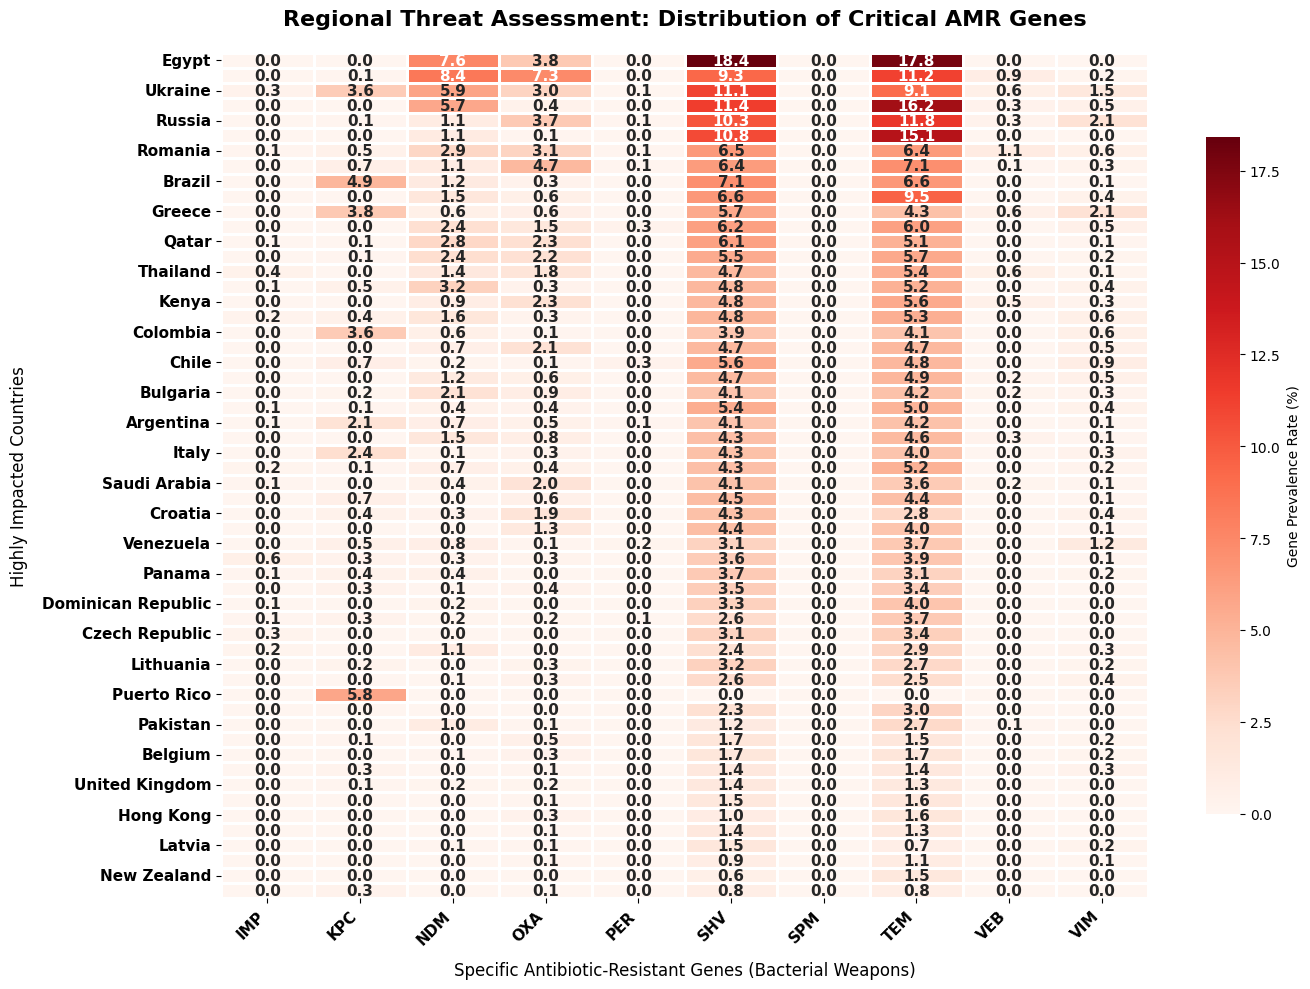

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter out countries where AMR genes are completely absent (all 0%)
# This removes the "sea of yellow" clutter at the top of your old chart
active_countries = country_gene[country_gene.sum(axis=1) > 2.0]

# 2. Sort countries by their total burden so the worst-hit regions naturally sit at the top
active_countries = active_countries.loc[active_countries.sum(axis=1).sort_values(ascending=False).index]

# 3. Create a clean, un-clustered heatmap with large text
plt.figure(figsize=(14, 10))

sns.heatmap(
    active_countries,
    cmap="Reds",          # Clean, universally understood color scale (Darker = Worse)
    annot=True,           # Keep the numbers visible
    fmt=".1f",            # Clean decimal format
    linewidths=1.0,       # Thicker gridlines separating the cells cleanly
    annot_kws={"size": 11, "weight": "bold"}, # Makes the numbers inside the cells large and bold!
    cbar_kws={'label': 'Gene Prevalence Rate (%)', 'shrink': 0.8}
)

# 4. Turn off the default crowded layout labels and use plain English
plt.title("Regional Threat Assessment: Distribution of Critical AMR Genes", fontsize=16, pad=20, weight="bold")
plt.xlabel("Specific Antibiotic-Resistant Genes (Bacterial Weapons)", fontsize=12, labelpad=10)
plt.ylabel("Highly Impacted Countries", fontsize=12, labelpad=10)

# Clean up axis ticks so they don't overlap
plt.xticks(rotation=45, ha='right', fontsize=11, weight="bold")
plt.yticks(rotation=0, fontsize=11, weight="bold")

plt.tight_layout()
plt.savefig("../../outputs/figures/easy_to_read_gene_matrix.png", dpi=300)
plt.show()

In [22]:
#Overall AMR burden by country
import matplotlib.pyplot as plt

# top 20 series and multiply by 100 to convert decimals to a clean index score
country_burden_scaled = country_burden.head(20) * 100

print(country_burden.head(20))

# 2. Plot the cleaned data
plt.figure(figsize=(12, 6))
country_burden_scaled.plot(kind="bar", color="skyblue", edgecolor="black")


plt.title("Top 20 Countries Ranked by Overall AMR Burden Index", fontsize=14, pad=15)
plt.ylabel("Mean AMR Burden Index (0 - 100%)", fontsize=11)
plt.xlabel("Country", fontsize=11)
plt.xticks(rotation=45, ha="right")  # Angled at 45 degrees so long names don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Adds clean background grid lines

plt.tight_layout()
plt.savefig("../../outputs/figures/amr_burden_by_country.png", dpi=300)
plt.show()

NameError: name 'country_burden' is not defined

Country
Egypt           0.476190
India           0.375022
Ukraine         0.352530
Nigeria         0.345149
Russia          0.294881
Ivory Coast     0.270627
Romania         0.213711
Turkey          0.204726
Brazil          0.201905
Cameroon        0.186548
Greece          0.177208
Morocco         0.169680
Qatar           0.166314
Jordan          0.160171
Thailand        0.144891
Guatemala       0.144426
Kenya           0.143038
Philippines     0.133245
Colombia        0.129505
South Africa    0.128426
Name: AMR_Burden, dtype: float64


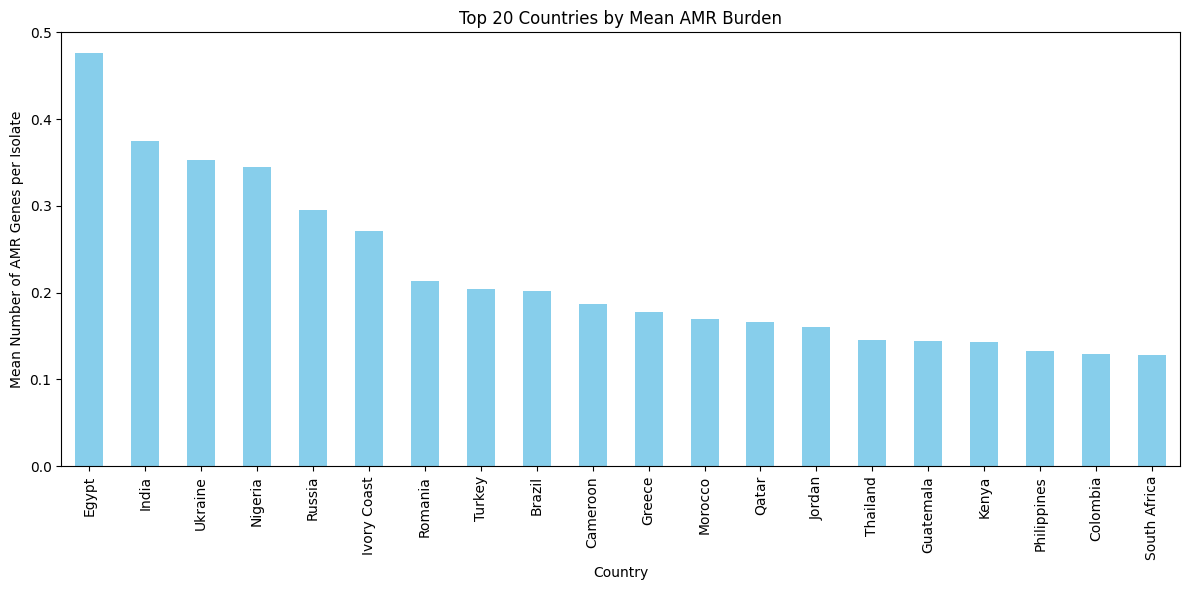

In [ ]:
#AMR burden by country
country_burden = (
    df1.groupby("Country")["AMR_Burden"]
       .mean()
       .sort_values(ascending=False)
)

print(country_burden.head(20))
#Visualize AMR burden by country
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
country_burden.head(20).plot(kind="bar", color="skyblue")
plt.title("Top 20 Countries by Mean AMR Burden")
plt.ylabel("Mean Number of AMR Genes per Isolate")
plt.xlabel("Country")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(
    "../../outputs/figures/amr_burden_by_country.png"
)
plt.show()

Source
Ileum                     2.000000
Colon                     0.191701
Rectum                    0.160422
Endotracheal aspirate     0.142080
Diverticulum              0.137705
Bronchoalveolar lavage    0.132605
Pancreas                  0.132293
Bladder                   0.128824
Prostate                  0.127517
Urine                     0.122884
Urethra                   0.117613
Stomach                   0.117417
Liver                     0.113469
Kidney                    0.107018
Intestinal: Other         0.104836
Ureter                    0.103506
Gall Bladder              0.102743
Peritoneal Fluid          0.102735
Thoracentesis Fluid       0.102717
Decubitus                 0.093682
Name: AMR_Burden, dtype: float64


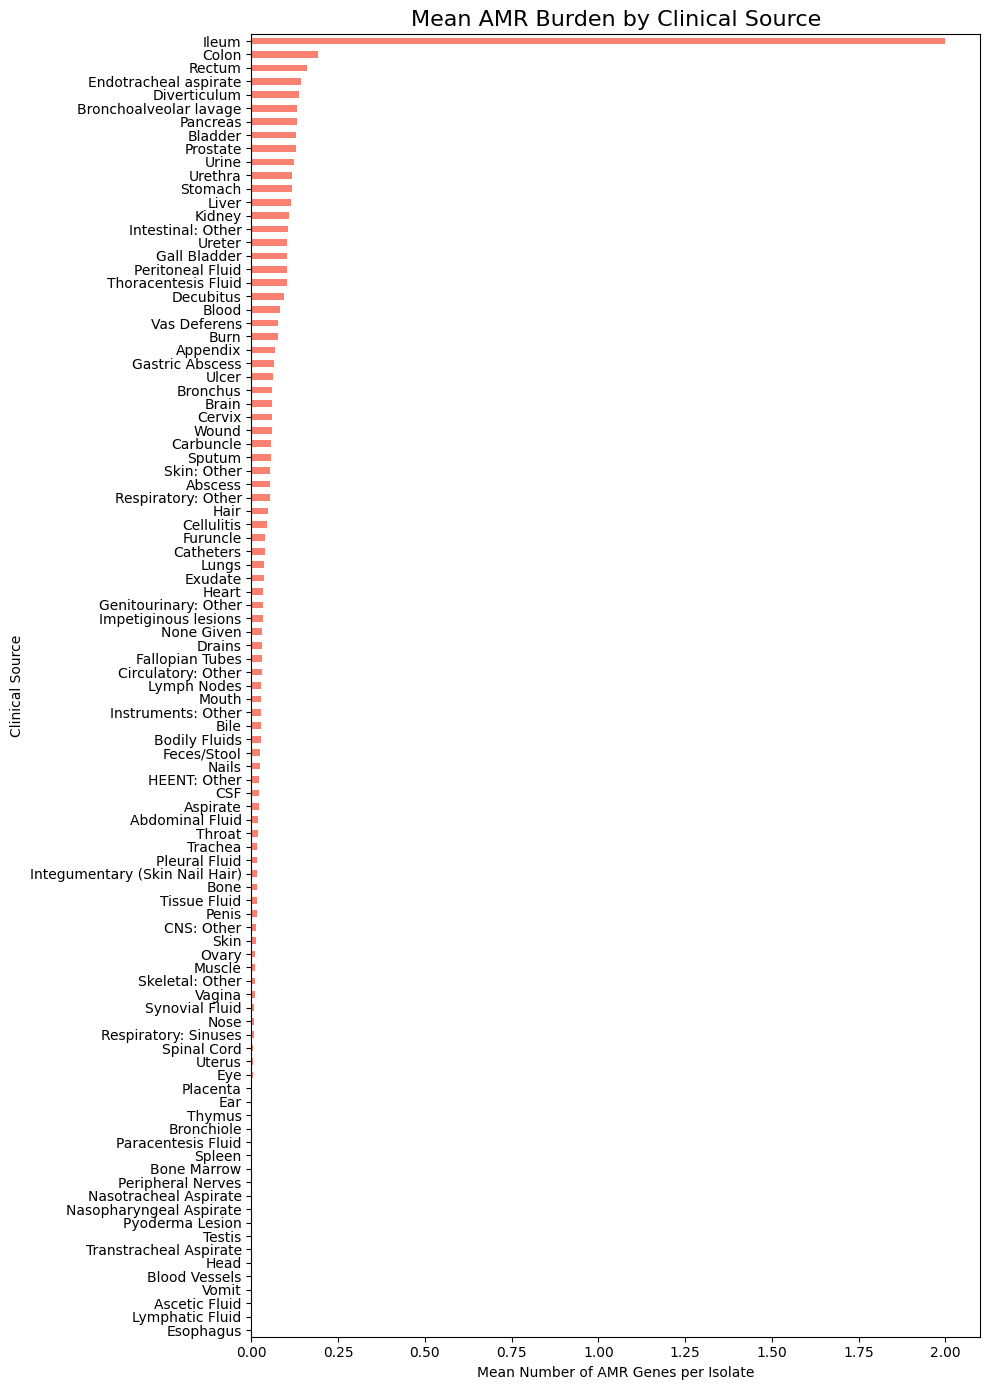

In [ ]:
#AMR Burden by source
source_burden = (
    df1.groupby("Source")["AMR_Burden"]
       .mean()
       .sort_values(ascending=False)
)

print(source_burden.head(20))

#Visualize AMR burden by source
# Sort from highest to lowest burden
source_burden = source_burden.sort_values(ascending=True)

plt.figure(figsize=(10, 14))

source_burden.plot(
    kind="barh",
    color="salmon"
)

plt.title("Mean AMR Burden by Clinical Source", fontsize=16)
plt.xlabel("Mean Number of AMR Genes per Isolate")
plt.ylabel("Clinical Source")

plt.tight_layout()

plt.savefig(
    "../../outputs/figures/amr_burden_by_source.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Group by source and calculate both the Mean and the Count of isolates
source_summary = df1.groupby("Source")["AMR_Burden"].agg(["mean", "count"])

# Sort by mean to match your plot logic
source_summary = source_summary.sort_values(by="mean", ascending=False)
print(source_summary)

                           mean  count
Source                                
Ileum                  2.000000      1
Colon                  0.191701   2916
Rectum                 0.160422   1708
Endotracheal aspirate  0.142080  47769
Diverticulum           0.137705    305
...                         ...    ...
Spleen                 0.000000     10
Paracentesis Fluid     0.000000      4
Bronchiole             0.000000      2
Pyoderma Lesion        0.000000      1
Esophagus              0.000000     13

[97 rows x 2 columns]


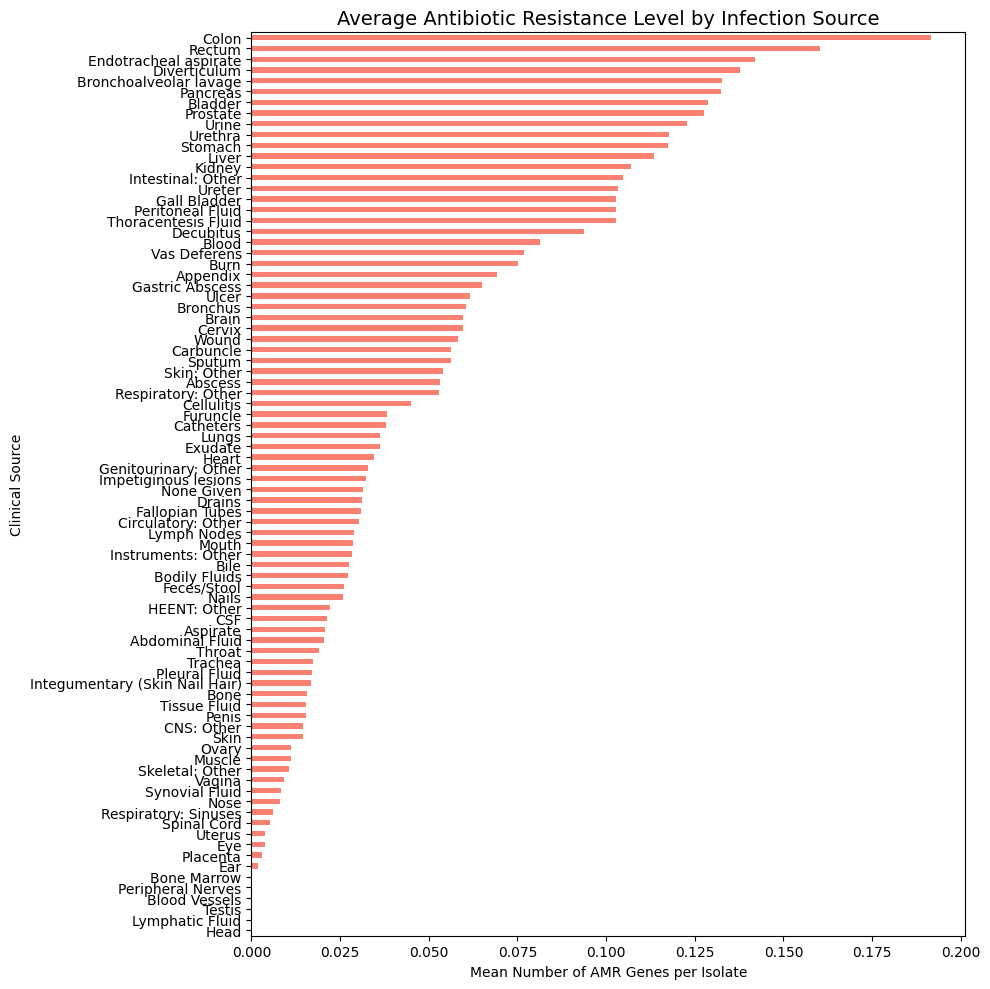

In [ ]:
# 1. Group and aggregate
source_summary = df1.groupby("Source")["AMR_Burden"].agg(["mean", "count"])

# 2. Filter out sources with fewer than 50 samples to remove noise
min_samples = 50
filtered_sources = source_summary[source_summary["count"] >= min_samples]

# 3. Sort for the horizontal bar chart (lowest to highest for plot structure)
plot_data = filtered_sources["mean"].sort_values(ascending=True)

# 4. Plot the filtered data
plt.figure(figsize=(10, 10))  # Slightly shorter since we removed noise
plot_data.plot(kind="barh", color="salmon")

plt.title("Average Antibiotic Resistance Level by Infection Source", fontsize=14) #f"Mean AMR Burden by Clinical Source (Sources with N >= {min_samples}
plt.xlabel("Mean Number of AMR Genes per Isolate")
plt.ylabel("Clinical Source")
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path

output_dir = Path("../../outputs/tables")
output_dir.mkdir(parents=True, exist_ok=True)

tables = {
    "gene_prevalence.csv": gene_prevalence,
    "country_gene_prevalence.csv": country_gene,
    "species_gene_prevalence.csv": species_gene,
    "country_amr_burden.csv": country_burden,
    "species_amr_burden.csv": species_burden,
    "source_amr_burden.csv": source_burden
}

for filename, table in tables.items():
    table.to_csv(output_dir / filename)

print(f"Saved {len(tables)} tables to {output_dir}")

Saved 6 tables to ../../outputs/tables


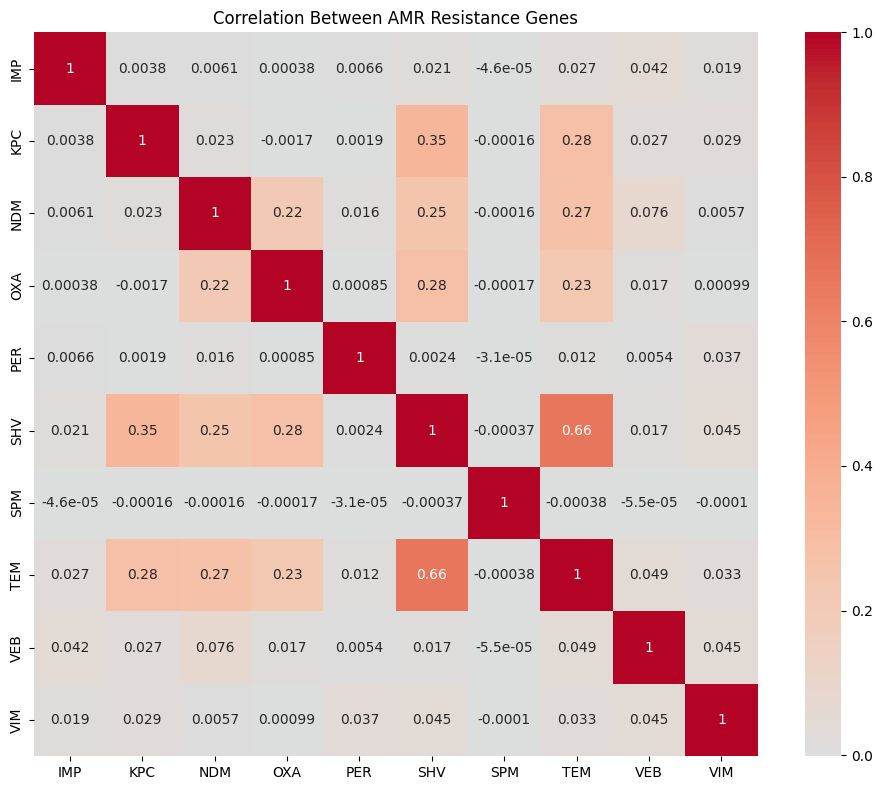

In [ ]:
#Gene Co-occurrence Analysis to identify common gene combinations
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation between gene presence
gene_corr = genes_binary.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    gene_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Between AMR Resistance Genes")

plt.tight_layout()

plt.savefig(
    "../../outputs/figures/gene_correlation_heatmap.png",
    dpi=300
)

plt.show()

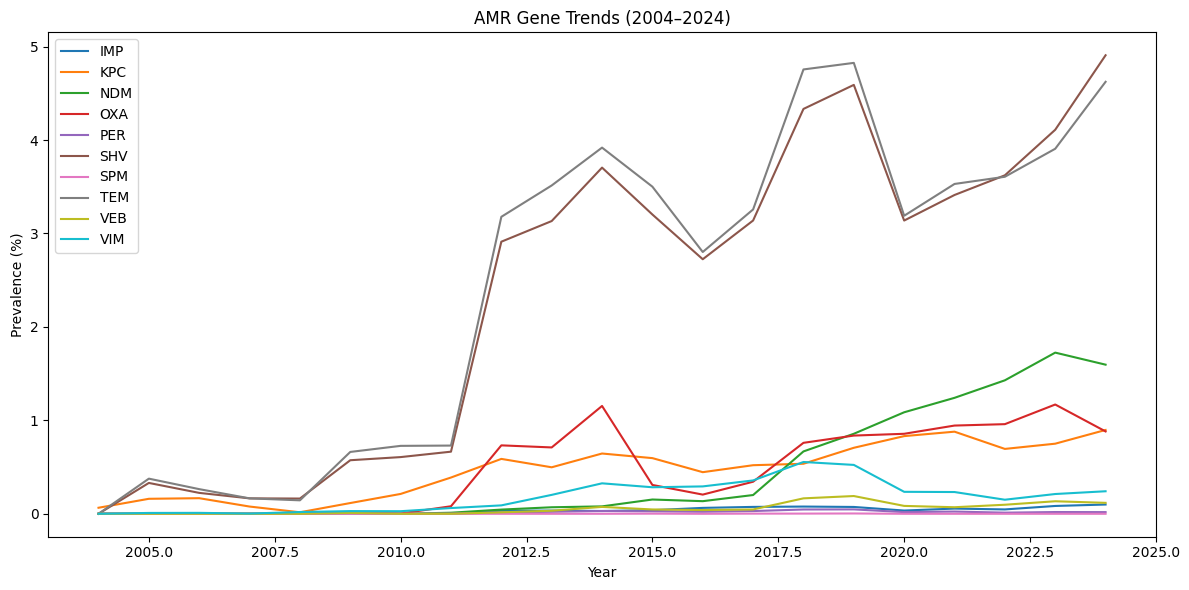

In [ ]:
#Gene Trends Over Time #Are resistance genes increasing globally?
gene_trend = (
    df1.groupby("Year")[gene_cols]
       .apply(lambda x: x.notna().mean()*100)
)

plt.figure(figsize=(12,6))

for gene in gene_cols:
    plt.plot(
        gene_trend.index,
        gene_trend[gene],
        label=gene
    )

plt.legend()

plt.xlabel("Year")

plt.ylabel("Prevalence (%)")

plt.title("AMR Gene Trends (2004–2024)")

plt.tight_layout()

plt.savefig(
    "../../outputs/figures/gene_trends.png",
    dpi=300
)

plt.show()

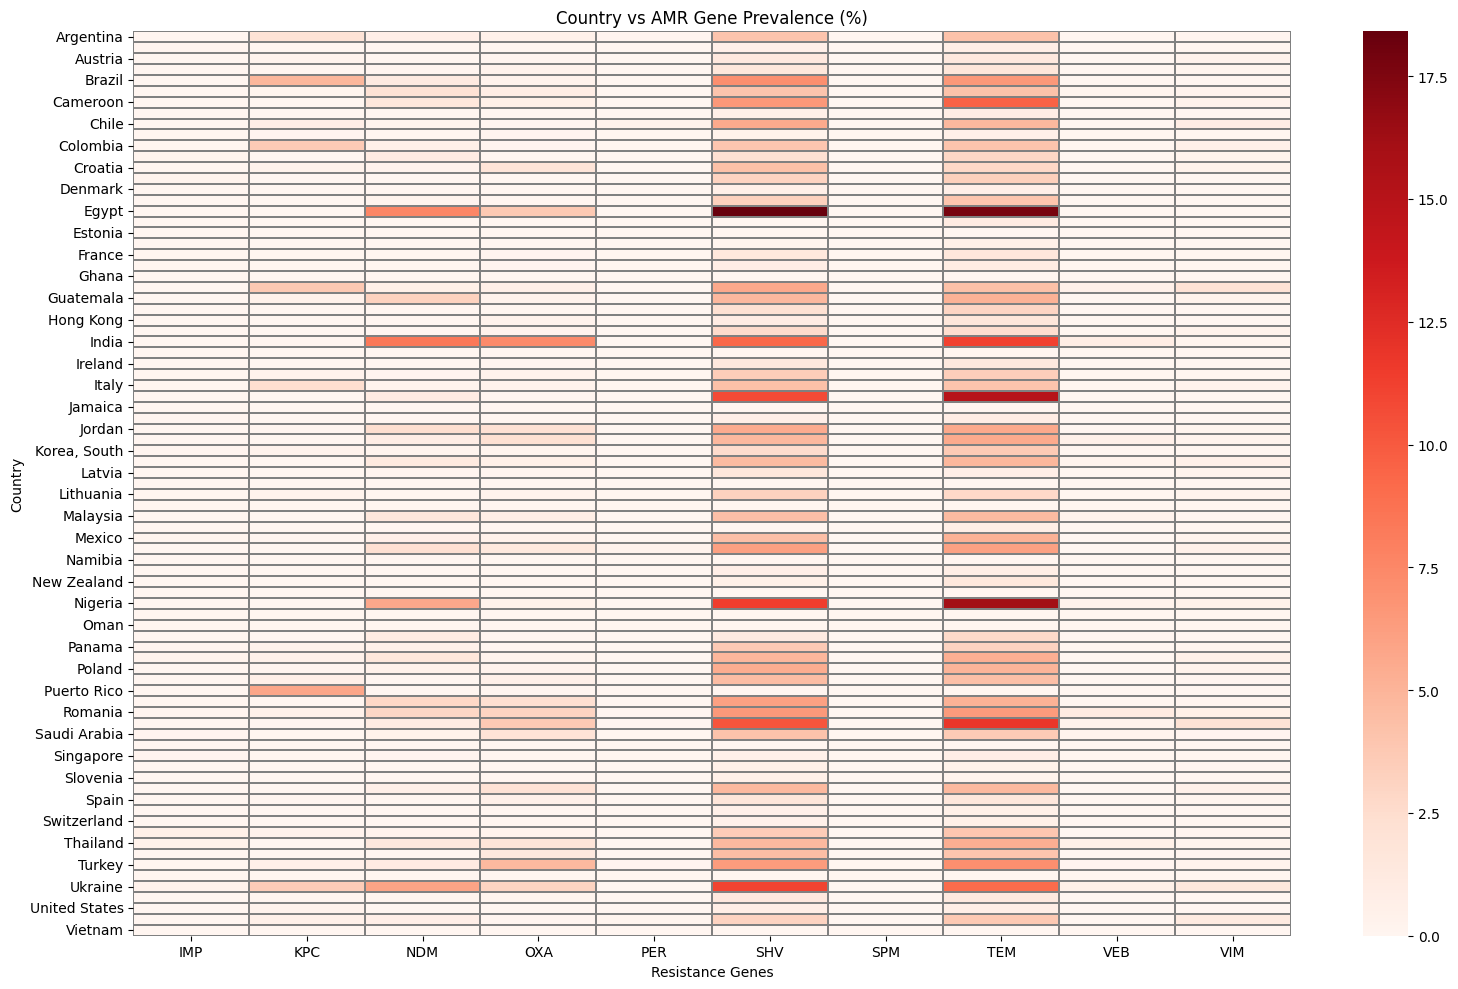

In [ ]:
#Hotspot analysis - prevalence of genes by country

country_gene = df1.groupby("Country")[gene_cols].apply(
    lambda x: x.notna().mean() * 100
)
#Visualize heatmap of gene prevalence by country
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

sns.heatmap(
    country_gene,
    cmap="Reds",
    linewidths=0.3,
    linecolor="gray"
)

plt.title("Country vs AMR Gene Prevalence (%)")
plt.xlabel("Resistance Genes")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    "../../outputs/figures/country_gene_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

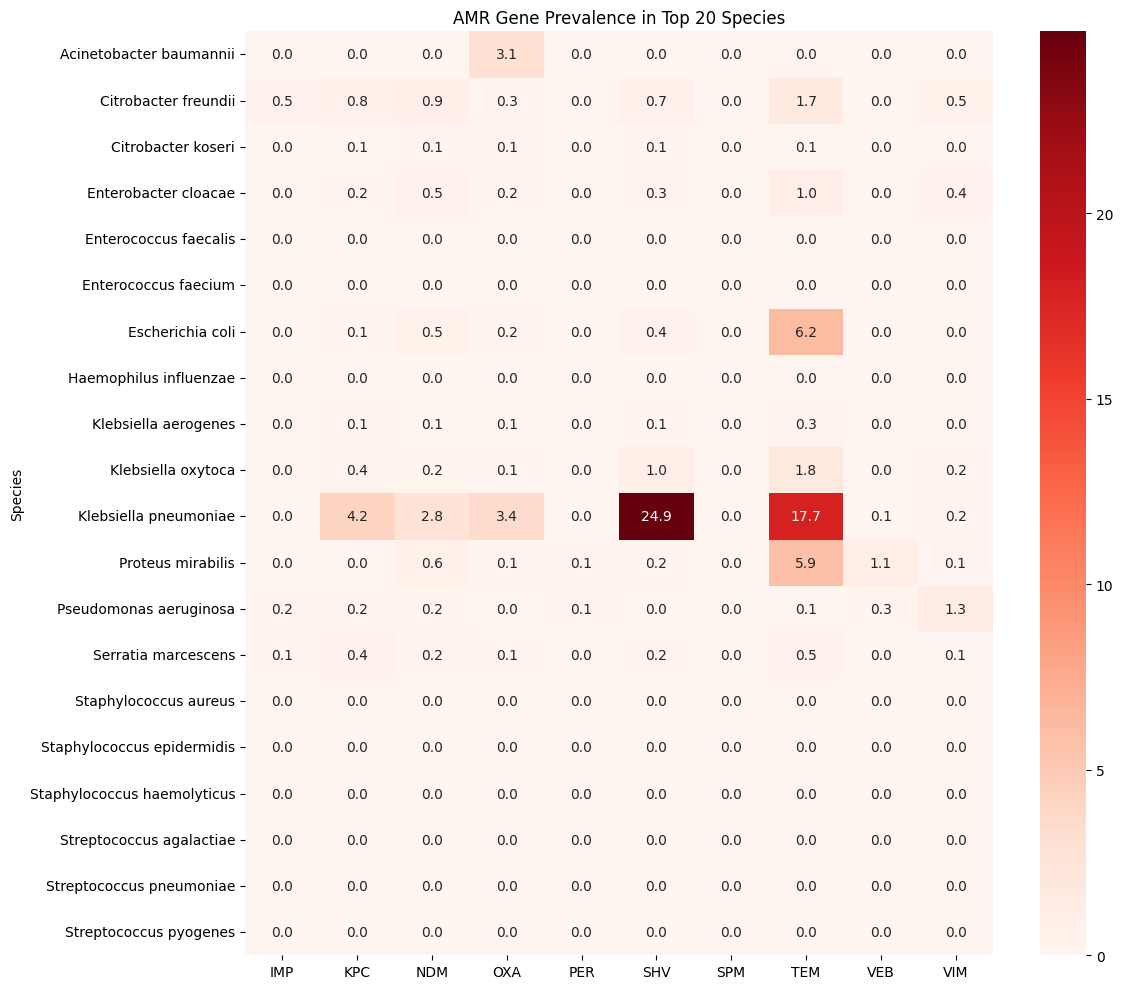

In [ ]:
top_species = (
    df1["Species"]
    .value_counts()
    .head(20)
    .index
)

species_gene = (
    df1[df1["Species"].isin(top_species)]
    .groupby("Species")[gene_cols]
    .apply(lambda x: x.notna().mean()*100)
)

plt.figure(figsize=(12,10))

sns.heatmap(
    species_gene,
    cmap="Reds",
    annot=True,
    fmt=".1f"
)

plt.title("AMR Gene Prevalence in Top 20 Species")

plt.tight_layout()

plt.savefig(
    "../../outputs/figures/top20_species_heatmap.png",
    dpi=300
)

plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. Define your weights
gene_weights = {
    "NDM": 5, "KPC": 5, "OXA": 4, "VIM": 4, "IMP": 4,
    "SPM": 3, "PER": 2, "VEB": 2, "TEM": 1, "SHV": 1
}

# Identify the gene columns actually present in df1
# (This matches columns like 'IMP', 'KPC', 'NDM', etc.)
gene_cols = [col for col in df1.columns if col in gene_weights]

# 3. Calculate scores based on whether the cell is NOT empty (not NaN)
priority_score = pd.DataFrame(index=df1.index)

for col in gene_cols:
    # .notna() turns text like "KPC-2" into True (1) and NaN into False (0)
    gene_present = df1[col].notna().astype(int)
    
    # Get the weight for this specific column
    weight = gene_weights[col]
    
    # Multiply presence (1 or 0) by the weight
    priority_score[col] = gene_present * weight

# Sum the scores and add to df1
df1["PriorityGeneScore"] = priority_score.sum(axis=1)

# 5. verify (sorting by highest score so you see the results!)
result_cols = ["PriorityGeneScore"] + gene_cols
print(df1[result_cols].sort_values(by="PriorityGeneScore", ascending=False).head(10))

        PriorityGeneScore    IMP    KPC    NDM      OXA  PER       SHV  SPM  \
968524                 16    NaN  KPC-3  NDM-1  OXA-232  NaN    SHV-11  NaN   
988309                 16    NaN  KPC-2  NDM-1      NaN  NaN     SHV-1  NaN   
786184                 16    NaN  KPC-3  NDM-1   OXA-48  NaN  SHV-OSBL  NaN   
830173                 15    NaN  KPC-2  NDM-1      NaN  NaN  SHV-OSBL  NaN   
992748                 15  IMP-8  KPC-2  NDM-1      NaN  NaN       NaN  NaN   
830154                 15    NaN  KPC-2  NDM-1      NaN  NaN       NaN  NaN   
745295                 15    NaN  KPC-2  NDM-1      NaN  NaN  SHV-OSBL  NaN   
998279                 15    NaN  KPC-2  NDM-1      NaN  NaN    SHV-27  NaN   
830176                 15    NaN  KPC-2  NDM-1      NaN  NaN  SHV-OSBL  NaN   
949986                 14    NaN  KPC-2  NDM-1      NaN  NaN       NaN  NaN   

                    TEM  VEB     VIM  
968524            TEM-1  NaN     NaN  
988309  TEM-1; TEM-Type  NaN  VIM-24  
786184       

In [ ]:
# Normalize the scores to a 0-1 scale for easier comparison
df1["PriorityGeneScore_Norm"] = (
    df1["PriorityGeneScore"]
    /
    df1["PriorityGeneScore"].max()
)

df1["AMR_Burden_Norm"] = (
    df1["AMR_Burden"]
    /
    df1["AMR_Burden"].max()
)
#Calculate a combined risk score (example: 80% weight to gene score, 20% to AMR burden)
df1["RiskScore"] = (
    0.8 * df1["PriorityGeneScore_Norm"]
    +
    0.2 * df1["AMR_Burden_Norm"]
)
#Convert to a 0–100 scale for easier interpretation
df1["RiskScore"] = df1["RiskScore"] * 100
# See top 10 isolates by Risk Score (SORTED from highest to lowest)
top_risk_isolates = df1[
    [
        "Species",
        "Country",
        "PriorityGeneScore",
        "AMR_Burden",
        "RiskScore"
    ]
].sort_values(by="RiskScore", ascending=False) # <--- This fixes it!

print(top_risk_isolates.head(10))

                      Species       Country  PriorityGeneScore  AMR_Burden  \
988309  Klebsiella pneumoniae      Colombia                 16           5   
786184  Klebsiella pneumoniae       Romania                 16           5   
968524  Klebsiella pneumoniae  South Africa                 16           5   
745295  Klebsiella pneumoniae      Colombia                 15           4   
830154       Escherichia coli      Colombia                 15           4   
992748   Citrobacter freundii        Taiwan                 15           4   
830173  Klebsiella pneumoniae      Colombia                 15           4   
830176  Klebsiella pneumoniae      Colombia                 15           4   
998279  Klebsiella pneumoniae      Colombia                 15           4   
815646  Klebsiella pneumoniae        Greece                 13           5   

        RiskScore  
988309      100.0  
786184      100.0  
968524      100.0  
745295       91.0  
830154       91.0  
992748       91.0  
8

In [ ]:
#Rank countries by average Risk Score tdentifies countries with the highest average isolate risk.
country_risk = (
    df1.groupby("Country")["RiskScore"]
       .mean()
       .sort_values(ascending=False)
)

print(country_risk.head(20)) 

Country
Egypt          6.380952
India          6.256536
Ukraine        5.829228
Nigeria        4.409204
Russia         3.782023
Romania        3.239392
Brazil         3.096342
Turkey         2.957465
Greece         2.929233
Ivory Coast    2.672167
Qatar          2.455250
Morocco        2.327495
Jordan         2.296960
Guatemala      2.158784
Cameroon       2.135787
Colombia       2.115037
Thailand       1.969591
Kenya          1.869620
Philippines    1.778422
Bulgaria       1.733915
Name: RiskScore, dtype: float64


In [ ]:
#Rank species by average Risk Score to identifies organisms carrying the highest weighted AMR risk.
species_risk = (
    df1.groupby("Species")["RiskScore"]
       .mean()
       .sort_values(ascending=False)
)

print(species_risk.head(20))

Species
Klebsiella pneumoniae          6.752922
Klebsiella spp                 5.547786
Providencia spp                4.006711
Providencia rettgeri           2.950804
Providencia stuartii           2.581928
Enterobacter hormaechi         2.523291
Raoultella planticola          1.600000
Citrobacter farmeri            1.539216
Enterobacter spp               1.288462
Citrobacter spp                1.246883
Citrobacter sedlakii           1.175258
Enterobacter xiangfangensis    1.053191
Enterobacter roggenkampii      1.043860
Citrobacter freundii           0.998353
Proteus mirabilis              0.984156
Serratia spp                   0.925676
Raoultella ornithinolytica     0.867580
Escherichia coli               0.851729
Escherichia spp                0.848684
Citrobacter amalonaticus       0.818605
Name: RiskScore, dtype: float64


In [ ]:
#Rank sources by average Risk Score to identify shows which specimen types with the highest weighted AMR risk.
source_risk = (
    df1.groupby("Source")["RiskScore"]
       .mean()
       .sort_values(ascending=False)
)

print(source_risk)

Source
Ileum                     18.000000
Colon                      2.788409
Rectum                     2.166862
Endotracheal aspirate      2.074630
Bronchoalveolar lavage     1.849614
                            ...    
Bronchiole                 0.000000
Pyoderma Lesion            0.000000
Nasotracheal Aspirate      0.000000
Peripheral Nerves          0.000000
Esophagus                  0.000000
Name: RiskScore, Length: 97, dtype: float64


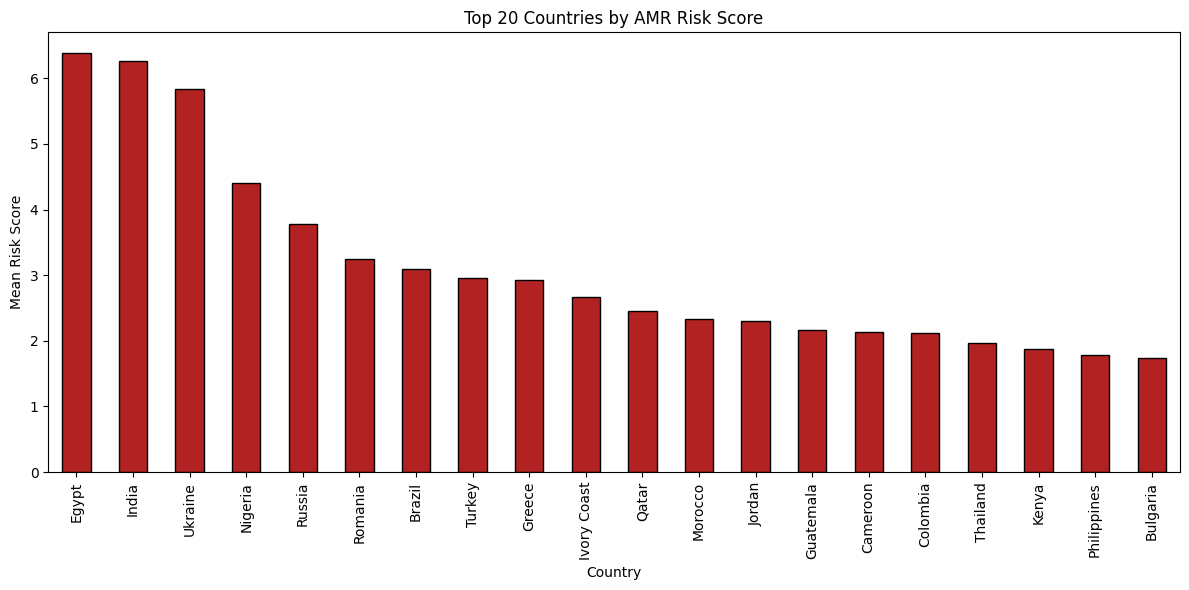

In [ ]:
#Visualize top 20 countries by Risk Score
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

country_risk.head(20).plot(
    kind="bar",
    color="firebrick",
    edgecolor="black"
)

plt.ylabel("Mean Risk Score")
plt.xlabel("Country")
plt.title("Top 20 Countries by AMR Risk Score")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../../outputs/figures/top20_country_risk.png",
    dpi=300
)

plt.show()

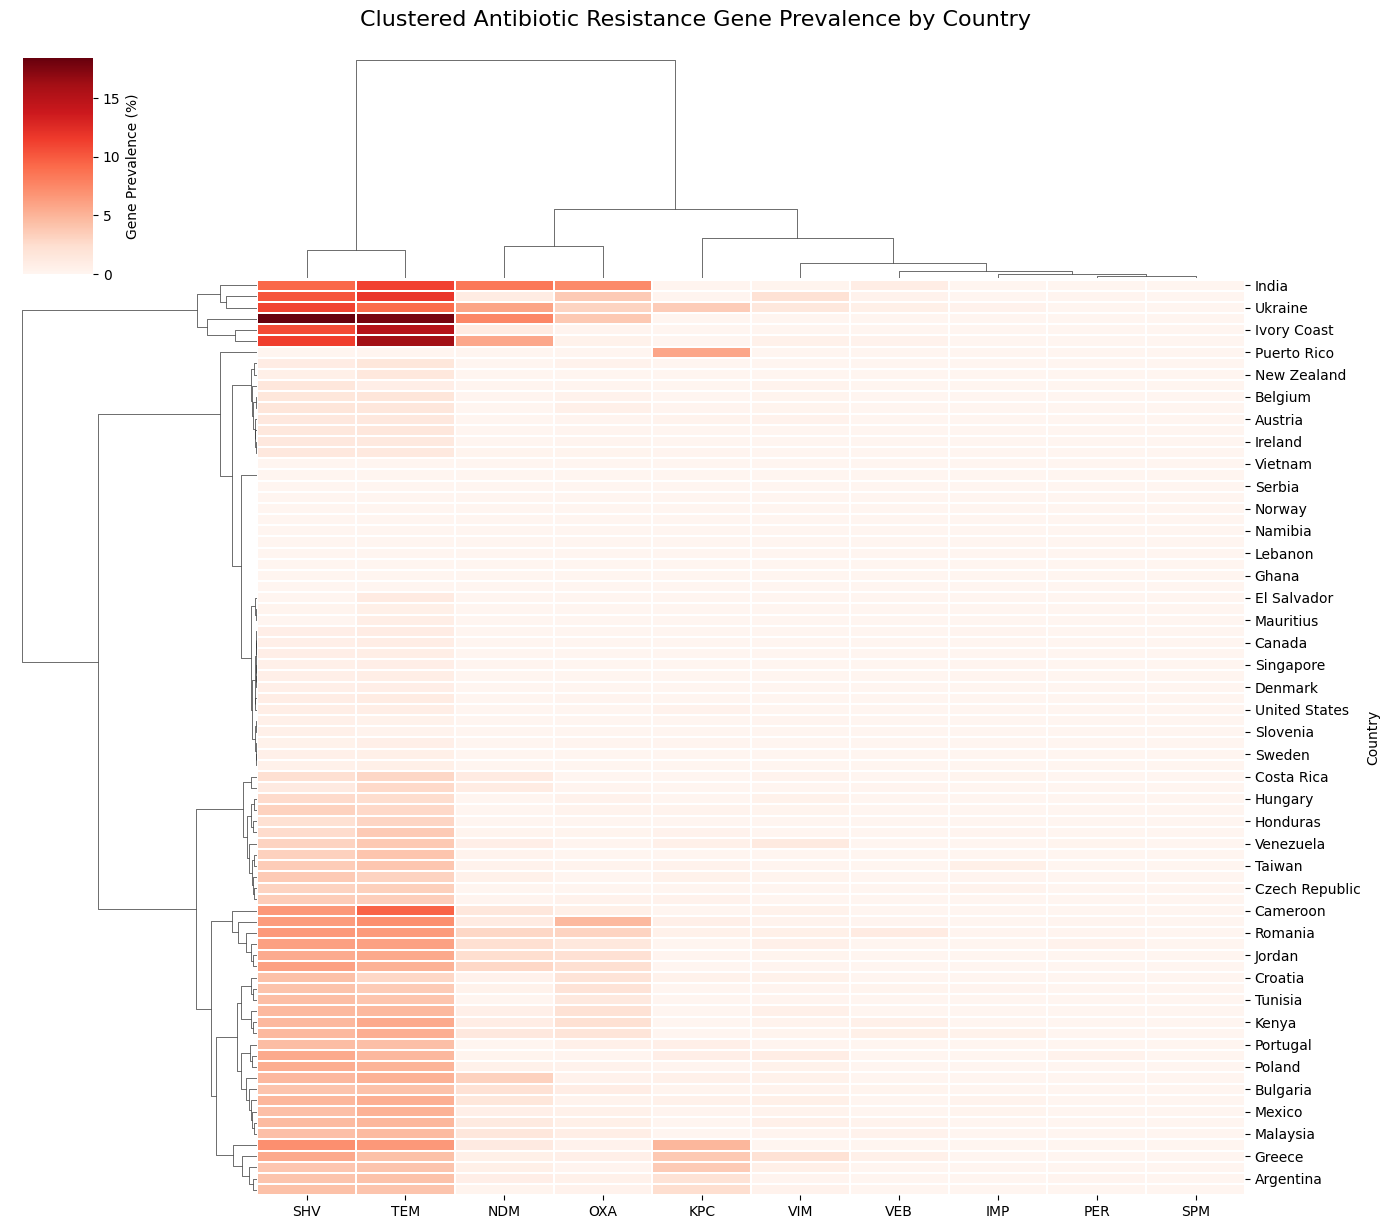

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter out countries with small sample sizes to eliminate statistical noise
min_isolates = 20  # Adjust this threshold based on your dataset size
country_counts = df1["Country"].value_counts()
eligible_countries = country_counts[country_counts >= min_isolates].index
df_filtered = df1[df1["Country"].isin(eligible_countries)]

# 2. Optimized, lightning-fast calculation of gene prevalence (%) per country
country_gene = df_filtered[gene_cols].notna().groupby(df_filtered["Country"]).mean() * 100

# 3. Generate the clustered heatmap
g = sns.clustermap(
    country_gene,
    cmap="Reds",
    linewidths=0.2,
    figsize=(14, 12),
    metric="euclidean",
    method="ward",
    cbar_kws={'label': 'Gene Prevalence (%)'} # Adds a clear label to your color bar
)

# 4. Safely apply a title to the Clustermap object
g.fig.suptitle("Clustered Antibiotic Resistance Gene Prevalence by Country", y=1.02, fontsize=16)

# 5. Save the figure (Avoid using plt.show() if running automated workflows)
g.savefig("../../outputs/figures/clustered_country_gene_heatmap.png", dpi=300, bbox_inches="tight")

In [ ]:
import pandas as pd

#  Filter out countries with small sample sizes to remove statistical noise (N < 20)
min_isolates = 20
country_counts = df1["Country"].value_counts()
eligible_countries = country_counts[country_counts >= min_isolates].index
df_filtered = df1[df1["Country"].isin(eligible_countries)]

# Calculate average clinical RiskScore per country
# This uses the 0-100 RiskScore we made earlier, which balances severity and gene counts.
country_map_data = (
    df_filtered.groupby("Country")["RiskScore"]
    .mean()
    .reset_index()
)

#  Rename columns cleanly for your mapping library
country_map_data.columns = ["Country", "Average_Clinical_Risk"]

#  View the top 10 highest-risk countries for the map
print(country_map_data.sort_values(by="Average_Clinical_Risk", ascending=False).head(10))

        Country  Average_Clinical_Risk
16        Egypt               6.380952
27        India               6.256536
77      Ukraine               5.829228
51      Nigeria               4.409204
62       Russia               3.782023
61      Romania               3.239392
4        Brazil               3.096342
75       Turkey               2.957465
22       Greece               2.929233
32  Ivory Coast               2.672167


In [ ]:
#Plot world map of AMR gene prevalence

import plotly.express as px

fig = px.choropleth(
    country_score,
    locations="Country",
    locationmode="country names",
    color="AMR_Prevalence",
    color_continuous_scale="Reds",
    title="Global AMR Gene Prevalence"
)
plt.savefig(
    "../../outputs/figures/world_map_AMR_Gene_Prevalence.png"
)

fig.show()

/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/2655328973.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


<Figure size 640x480 with 0 Axes>

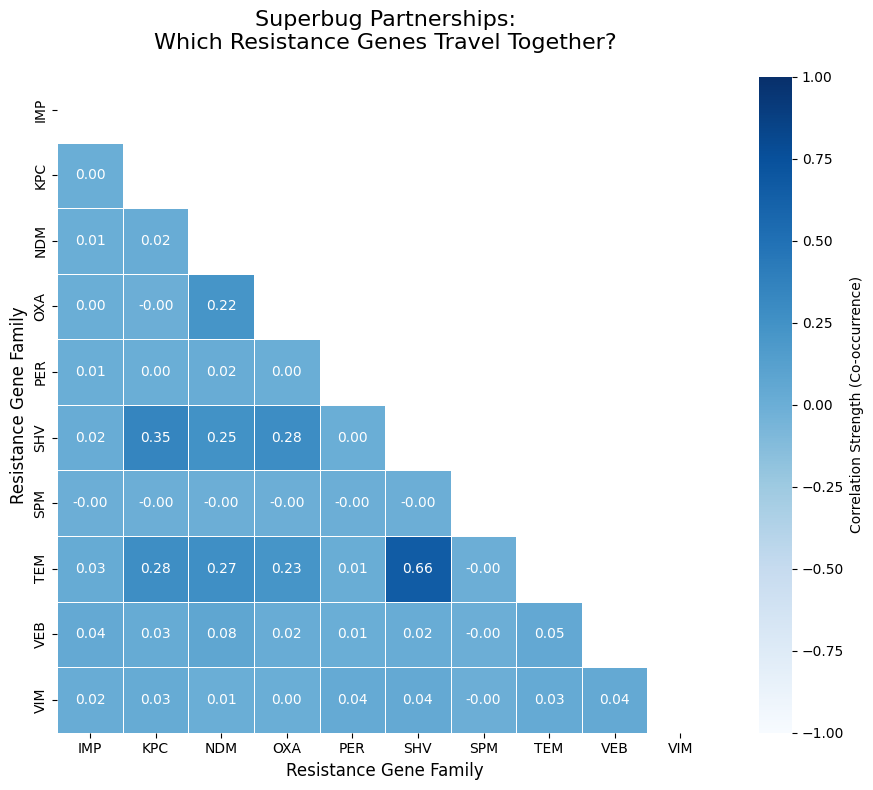

In [ ]:
#Netework analysis of gene co-occurrence to identify common gene combinations
#Corelation heat map of gene co-occurrence to identify common gene combinations
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert the gene columns in df1 to a clean binary matrix (True/False to 1/0)
binary_genes = df1[gene_cols].notna().astype(int)

# 2. Calculate the correlation matrix (Phi Coefficient / Pearson)
# This measures how strongly the presence of one gene predicts the presence of another.
co_occurrence_matrix = binary_genes.corr()

# 3. Set up the plotting environment
plt.figure(figsize=(10, 8))

# Create a mask to hide the upper triangle (since a correlation matrix is symmetrical)
mask = np.triu(np.ones_like(co_occurrence_matrix, dtype=bool))

# 4. Draw the heatmap
sns.heatmap(
    co_occurrence_matrix,
    mask=mask,
    cmap="Blues",  # Use blue to visually differentiate this from your country heatmap
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,  # Displays the actual correlation numbers in the boxes
    fmt=".2f",
    cbar_kws={"label": "Correlation Strength (Co-occurrence)"},
)

# 5. Clear, non-technical title
plt.title(
    "Superbug Partnerships:\nWhich Resistance Genes Travel Together?",
    fontsize=16,
    pad=20,
)
plt.xlabel("Resistance Gene Family", fontsize=12)
plt.ylabel("Resistance Gene Family", fontsize=12)

plt.tight_layout()
plt.savefig("../../outputs/figures/gene_co_occurrence_heatmap.png", dpi=300)
plt.show()

In [ ]:
#map risk score
fig = px.choropleth(
    country_risk,
    locations="Country",
    locationmode="country names",
    color="AMR_RiskScore",
    color_continuous_scale="Reds",
    title="AMR Risk Score by Country"
)

fig.show()

/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/1607542841.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [ ]:
import plotly.express as px
import pandas as pd

# 1. Aggregate your already-calculated RiskScore by Year and Country
# This gives you one clear, weighted clinical danger number per country, per year.
time_country_risk = (
    df1.groupby(["Year", "Country"])["RiskScore"]
    .mean()
    .reset_index()
)

# 2. Generate the Interactive Time-Slider Map for Risk
fig_risk = px.choropleth(
    time_country_risk,
    locations="Country",
    locationmode="country names",
    color="RiskScore",
    animation_frame="Year",
    color_continuous_scale="Reds",
    range_color=[0, 100],  # Stays locked 0-100 across the timeline
    title="Global Clinical AMR Risk Score Trends Over Time",
    labels={"RiskScore": "Avg Risk Score (0-100)"}
)

# Clean up styling and map projection
fig_risk.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
    width=1000,
    height=600
)

# Save as interactive webpage (Bypasses kaleido image export errors)
fig_risk.write_html("../../outputs/figures/time_slider_risk_map.html")
fig_risk.show()

/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/4236434862.py:13: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig_risk = px.choropleth(


In [ ]:
import plotly.express as px
import pandas as pd

# 1. Melt the dataframe to long format
df_long = df1.melt(
    id_vars=["Country", "Year", "Species"],
    value_vars=gene_cols,
    var_name="Gene",
    value_name="Presence"
)

# 2. Convert text/NaN presence to binary 1s and 0s
df_long["Presence"] = df_long["Presence"].notna().astype(int)

# 3. Aggregate data by Year and Country to track the average over time
time_country = df_long.groupby(["Year", "Country"])["Presence"].mean().reset_index()

# Multiply by 100 to change decimals to a clean 0-100% scale for the map
time_country["Resistance_Level_%"] = time_country["Presence"] * 100

# 4. Generate the Interactive Time-Slider Map
fig = px.choropleth(
    time_country,
    locations="Country",
    locationmode="country names",
    color="Resistance_Level_%",
    animation_frame="Year",      # Creates the timeline slider at the bottom
    color_continuous_scale="Reds",
    range_color=[0, 100],         # Keeps the color scale consistent across years
    title="Global Antibiotic Resistance Spread Over Time",
    labels={"Resistance_Level_%": "Avg Gene Prevalence (%)"}
)

# Fix map layout styling
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    width=1000,
    height=600
)

# 5. CORRECT WAY TO SAVE A PLOTLY FIGURE
# Note: Requires the 'kaleido' package installed (`pip install kaleido`)
#fig.write_image("../../outputs/figures/time_slider_map.png", scale=2)

# 6. Display the interactive map in your browser/notebook
fig.show()

/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/561322908.py:22: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [ ]:
import plotly.express as px
import pandas as pd

# 1. Melt the dataframe to long format
df_long = df1.melt(
    id_vars=["Country", "Year", "Species"],
    value_vars=gene_cols,
    var_name="Gene",
    value_name="Presence"
)

# 2. Convert text/NaN presence to binary 1s and 0s
df_long["Presence"] = df_long["Presence"].notna().astype(int)

# 3. Aggregate data by Year, Country, and Gene, then scale to percentages
time_country_gene = df_long.groupby(["Year", "Country", "Gene"])["Presence"].mean().reset_index()
time_country_gene["Prevalence_%"] = time_country_gene["Presence"] * 100

# 4. Generate the Interactive Multi-Gene Map Grid
fig = px.choropleth(
    time_country_gene,
    locations="Country",
    locationmode="country names",
    color="Prevalence_%",
    animation_frame="Year",
    facet_col="Gene",           
    facet_col_wrap=3,           # <-- CRITICAL: Wraps maps every 3 columns into a clean grid!
    color_continuous_scale="Reds",
    range_color=[0, 100],        # <-- Keeps color baseline steady across animation years
    title="Individual AMR Gene Prevalence and Global Spread Over Time"
)

# Adjust dimensions so the grid has room to breathe
fig.update_layout(
    width=1200,
    height=900,
    geo=dict(showframe=False, showcoastlines=True)
)

# 5. FIXED SAVE METHOD: Bypasses matplotlib/kaleido by saving as an interactive HTML webpage
fig.write_html("../../outputs/figures/time_slider_map.html")

# 6. Render the interactive map
fig.show()

/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/978051289.py:20: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [ ]:
def gene_map(df_long, gene_name):
    # filter for ONLY the requested gene
    gene_df = df_long[df_long["Gene"] == gene_name].copy()

    # Group by country for just that isolated gene, converted to a clean % scale
    gene_country = gene_df.groupby("Country")["Presence"].mean().reset_index()
    gene_country["Prevalence_%"] = gene_country["Presence"] * 100

    # Create a clean, single-focused map
    fig = px.choropleth(
        gene_country,
        locations="Country",
        locationmode="country names",
        color="Prevalence_%",
        color_continuous_scale="Reds",
        range_color=[0, 100], # Keeps scale consistent
        title=f"Global Epidemiology & Distribution of the {gene_name} Gene",
        labels={"Prevalence_%": "Prevalence (%)"}
    )

    fig.show()
gene_map(df_long, "CTX-M")
gene_map(df_long, "NDM")
gene_map(df_long, "OXA")
gene_map(df_long, "KPC")
gene_map(df_long, "TEM")
gene_map(df_long, "SHV")

/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/3764380132.py:10: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/3764380132.py:10: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/3764380132.py:10: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/3764380132.py:10: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/3764380132.py:10: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/3764380132.py:10: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [ ]:
# Gene frequency
gene_freq = df_long.groupby("Gene")["Presence"].mean()

# Smoothed inverse frequency weights
gene_weights = 1 / (gene_freq + 1e-6)

# Normalize weights
gene_weights = gene_weights / gene_weights.max()

# Map weights
df_long["Weight"] = df_long["Gene"].map(gene_weights)

# Weighted presence
df_long["WeightedPresence"] = df_long["Presence"] * df_long["Weight"]

# Country risk score (correct aggregation)
country_risk = df_long.groupby("Country").apply(
    lambda x: x["WeightedPresence"].sum() / len(x)
).reset_index()

country_risk.columns = ["Country", "AMR_RiskScore"]

# Normalize
country_risk["AMR_RiskScore"] = (
    country_risk["AMR_RiskScore"] /
    country_risk["AMR_RiskScore"].max()
) * 100

In [ ]:
import os  
import plotly.express as px

def save_gene_maps_over_time(df_long, output_dir="../../outputs/figures"):
    os.makedirs(output_dir, exist_ok=True)
    
    # Extract every unique gene variant in your dataset automatically
    genes = df_long["Gene"].unique()

    for gene in genes:
        # Cleanly isolate the data for just this single gene mutation
        gene_df = df_long[df_long["Gene"] == gene].copy()

        #  Group by BOTH Country and Year so we preserve the timeline slider animation
        gene_country_time = gene_df.groupby(["Country", "Year"])["Presence"].mean().reset_index()
        
        # Convert to an easy-to-read 0-100% scale
        gene_country_time["Prevalence_%"] = gene_country_time["Presence"] * 100

        # Build the dynamic, animated choropleth map
        fig = px.choropleth(
            gene_country_time,
            locations="Country",
            locationmode="country names",
            color="Prevalence_%",
            animation_frame="Year",
            color_continuous_scale="Reds",
            range_color=[0, 100],
            title=f"Global Epidemiology & Spread of the {gene} Gene Over Time",
            labels={"Prevalence_%": "Gene Prevalence (%)"}
        )

        fig.update_layout(
            geo=dict(showframe=False, showcoastlines=True),
            width=1000,
            height=600
        )

        # 7. Safe HTML Export
        html_path = f"{output_dir}/{gene}_time_slider_map.html"
        fig.write_html(html_path)

        print(f"✅ Successfully exported animated map for: {gene}")

# Run the automated pipeline
save_gene_maps_over_time(df_long)

/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/3597091535.py:22: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


✅ Successfully exported animated map for: IMP


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/3597091535.py:22: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


✅ Successfully exported animated map for: KPC


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/3597091535.py:22: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


...

/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/3597091535.py:22: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


✅ Successfully exported animated map for: TEM


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/3597091535.py:22: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


✅ Successfully exported animated map for: VEB
✅ Successfully exported animated map for: VIM


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/3597091535.py:22: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [ ]:
import plotly.express as px

def save_gene_maps(df_long, output_dir="outputs/figures"):

    import os
import plotly.express as px

def save_gene_maps_over_time(df_long, output_dir="../../outputs/figures"):
    # 1. Ensure the output directory exists so Python doesn't throw a FileNotFoundError
    os.makedirs(output_dir, exist_ok=True)
    
    # 2. Extract every unique gene variant in your dataset automatically
    genes = df_long["Gene"].unique()

    for gene in genes:
        # 3. Cleanly isolate the data for just this single gene mutation
        gene_df = df_long[df_long["Gene"] == gene].copy()

        # 4. Group by BOTH Country and Year so we preserve the timeline slider animation
        gene_country_time = gene_df.groupby(["Country", "Year"])["Presence"].mean().reset_index()
        
        # 5. Convert to an easy-to-read 0-100% scale
        gene_country_time["Prevalence_%"] = gene_country_time["Presence"] * 100

        # 6. Build the dynamic, animated choropleth map
        fig = px.choropleth(
            gene_country_time,
            locations="Country",
            locationmode="country names",
            color="Prevalence_%",
            animation_frame="Year",          # <-- Restores the timeline animation functionality
            color_continuous_scale="Reds",
            range_color=[0, 100],            # <-- Locks scale bounds to make time jumps comparable
            title=f"Global Epidemiology & Spread of the {gene} Gene Over Time",
            labels={"Prevalence_%": "Gene Prevalence (%)"}
        )

        fig.update_layout(
            geo=dict(showframe=False, showcoastlines=True),
            width=1000,
            height=600
        )

        # 7. Safe HTML Export: Works flawlessly on your Mac without external engine compilation
        html_path = f"{output_dir}/{gene}_time_slider_map.html"
        fig.write_html(html_path)

        print(f"✅ Successfully exported animated map for: {gene}")

# Run the automated pipeline
save_gene_maps_over_time(df_long)

/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/2579061541.py:26: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


✅ Successfully exported animated map for: IMP


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/2579061541.py:26: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


✅ Successfully exported animated map for: KPC


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/2579061541.py:26: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


...

/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/2579061541.py:26: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


✅ Successfully exported animated map for: TEM


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/2579061541.py:26: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


✅ Successfully exported animated map for: VEB
✅ Successfully exported animated map for: VIM


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_4234/2579061541.py:26: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


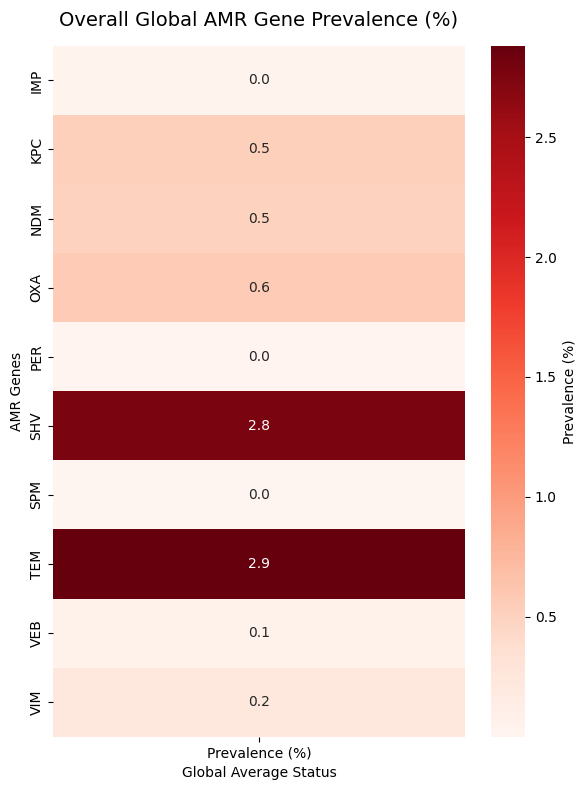

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate global prevalence directly from your df_long data
prevalence_df = (
    df_long.groupby("Gene")["Presence"]
    .mean()
    .reset_index()
)

# Convert the decimals to percentages (e.g., 0.45 -> 45.0%)
prevalence_df["Prevalence (%)"] = prevalence_df["Presence"] * 100

# Set 'Gene' as the index so it labels our heatmap axes correctly
prevalence_df = prevalence_df.set_index("Gene")[["Prevalence (%)"]]

#  Draw the summary heatmap
plt.figure(figsize=(6, 8))  # Adjusted size to fit a nice vertical stack

sns.heatmap(
    prevalence_df,  # No need for .T anymore, it will stack beautifully
    cmap="Reds",
    annot=True,
    fmt=".1f",
    cbar_kws={'label': 'Prevalence (%)'}
)

plt.title("Overall Global AMR Gene Prevalence (%)", fontsize=14, pad=15)
plt.xlabel("Global Average Status")
plt.ylabel("AMR Genes")
plt.tight_layout()

# Save in figures folder
plt.savefig("../../outputs/figures/overall_gene_prevalence.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd

# Pivot to see the progression side-by-side
trend_matrix = yearly_trends.pivot(index="Year", columns="Gene", values="Prevalence_%")
print("Year-over-Year Gene Growth Trajectories:")
print(trend_matrix.pct_change().dropna() * 100) # Shows percentage growth shifts

# Calculate yearly global prevalence for each gene
yearly_trends = df_long.groupby(["Year", "Gene"])["Presence"].mean().reset_index()
yearly_trends["Prevalence_%"] = yearly_trends["Presence"] * 100

#  Pivot to see the progression side-by-side
trend_matrix = yearly_trends.pivot(index="Year", columns="Gene", values="Prevalence_%")
print(trend_matrix)

#Calculate the percentage growth shifts (Year-over-Year)
growth_matrix = trend_matrix.pct_change().dropna() * 100
print(growth_matrix)

# 4. Save both metrics directly into your tables directory
# Table A: The actual prevalence percentage per year
trend_matrix.to_csv("../../outputs/tables/amr_gene_yearly_prevalence.csv")

# Table B: The relative speed/growth rate changes year-over-year
growth_matrix.to_csv("../../outputs/tables/amr_gene_yoy_growth_rates.csv")

print("✅ Successfully saved both trend tables to 'outputs/tables/'!")

Year-over-Year Gene Growth Trajectories:
Gene        IMP        KPC         NDM         OXA        PER        SHV  \
Year                                                                       
2015  29.602678  -7.643137   92.459978  -73.251536 -11.870179 -13.548615   
2016  63.828846 -25.242961  -11.616670  -33.444531 -17.866555 -14.945375   
2017  16.723975  16.741488   48.662796   67.046833  35.363617  15.217822   
2018   4.900127   3.000678  232.389708  121.268390  57.767123  38.041331   
2019  -5.374720  31.878703   28.307020   10.228583   2.305903   5.941324   
2020 -52.519791  17.704025   26.871761    2.280284 -61.312422 -31.629942   

Gene         SPM        TEM         VEB        VIM  
Year                                                
2015         inf -10.669807  -37.192548 -12.907000  
2016 -100.000000 -19.966969  -13.121067   3.202460  
2017         inf  16.253459   15.172825  21.780417  
2018   21.910959  45.997686  256.702434  55.319250  
2019   66.720731   1.477401   15

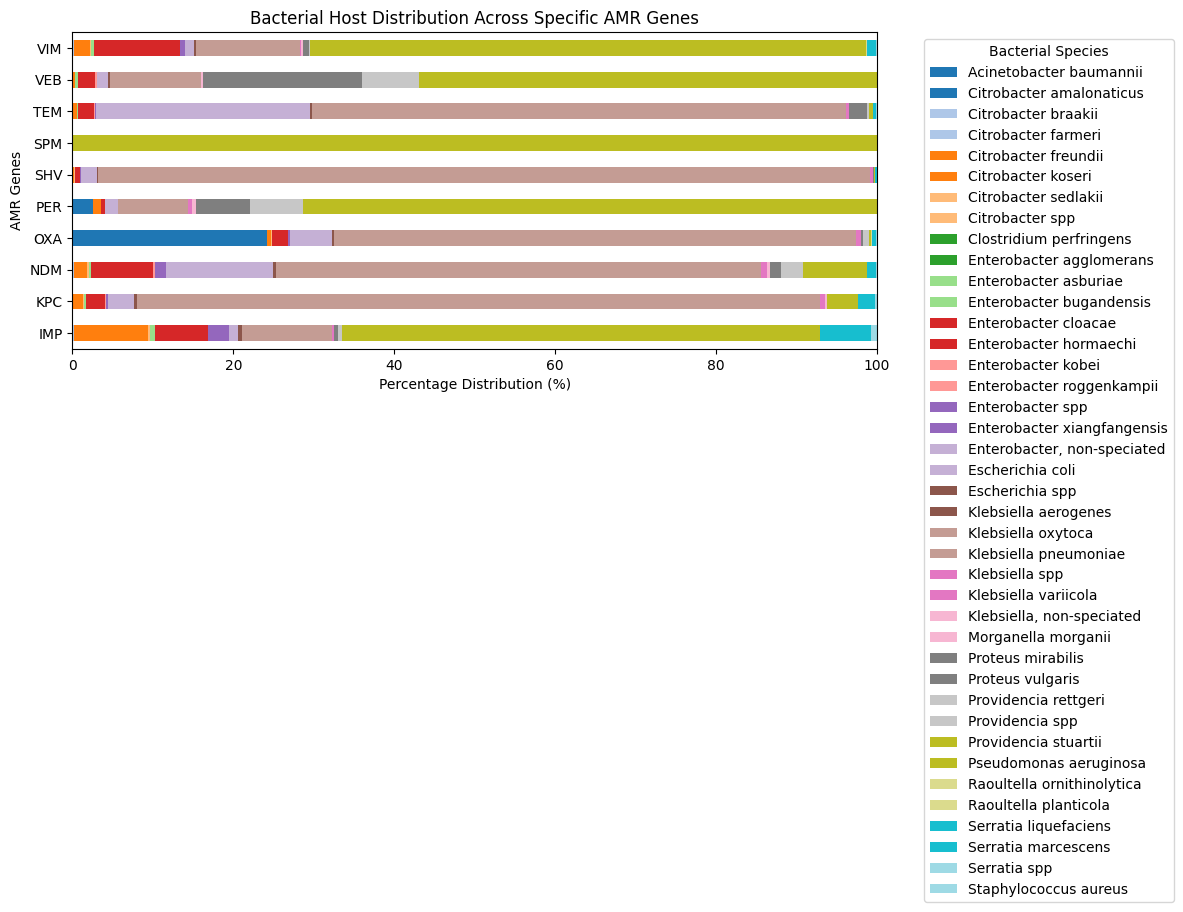

In [ ]:
# Cross-tabulate Species vs Genes
species_gene_matrix = pd.crosstab(
    df_long[df_long["Presence"] == 1]["Species"], 
    df_long[df_long["Presence"] == 1]["Gene"],
    normalize='columns' # Shows percentage distribution of each gene across species
) * 100

# Plot as a stacked horizontal bar chart
species_gene_matrix.T.plot(kind="barh", stacked=True, figsize=(12, 7), cmap="tab20")
plt.title("Bacterial Host Distribution Across Specific AMR Genes")
plt.xlabel("Percentage Distribution (%)")
plt.ylabel("AMR Genes")
plt.legend(title="Bacterial Species", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()